In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
set_config(transform_output="pandas")

In [2]:
#Read the DataSet file

In [3]:
df=pd.read_csv('Titanic-Dataset.csv')
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
df['FamilySize'] = df['SibSp'] + df['Parch']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.904602
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,10.000000


In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [8]:
df.describe(include=[object])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [9]:
print(df["Name"].value_counts())
print(df["Sex"].value_counts())
print(df["Ticket"].value_counts())
print(df["Cabin"].value_counts())
print(df["Embarked"].value_counts())

Name
Braund, Mr. Owen Harris                     1
Boulos, Mr. Hanna                           1
Frolicher-Stehli, Mr. Maxmillian            1
Gilinski, Mr. Eliezer                       1
Murdlin, Mr. Joseph                         1
                                           ..
Kelly, Miss. Anna Katherine "Annie Kate"    1
McCoy, Mr. Bernard                          1
Johnson, Mr. William Cahoone Jr             1
Keane, Miss. Nora A                         1
Dooley, Mr. Patrick                         1
Name: count, Length: 891, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64
Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1

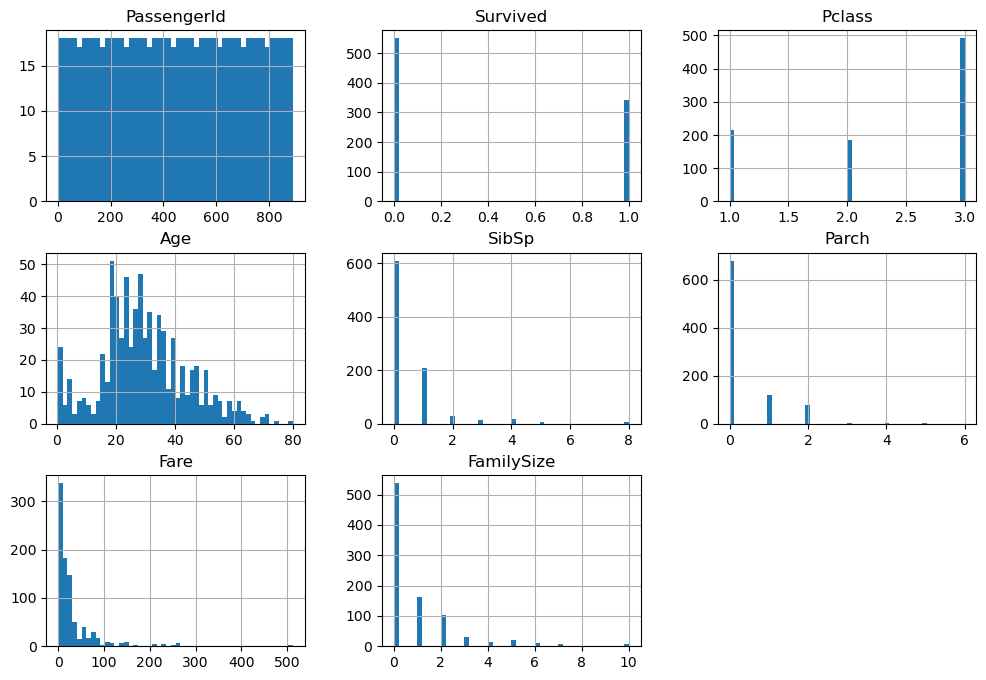

In [10]:
df.hist(bins=50, figsize=(12,8))
plt.show()

In [11]:
#Handling missing values

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
dtype: int64

In [13]:
df.drop(columns=['PassengerId'], inplace=True) 
df.drop(columns=['Name'], inplace=True) 
df.drop(columns=['Cabin'], inplace=True) 
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked', 'FamilySize'],
      dtype='object')

In [14]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")
df['Age'] = imputer.fit_transform(df[['Age']])
imputer = SimpleImputer(strategy='most_frequent')
df['Embarked'] = imputer.fit_transform(df[['Embarked']])

In [15]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      0
FamilySize    0
dtype: int64

In [16]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked', 'FamilySize'],
      dtype='object')

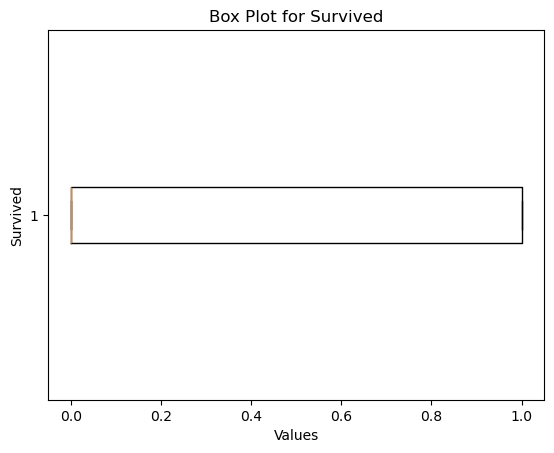

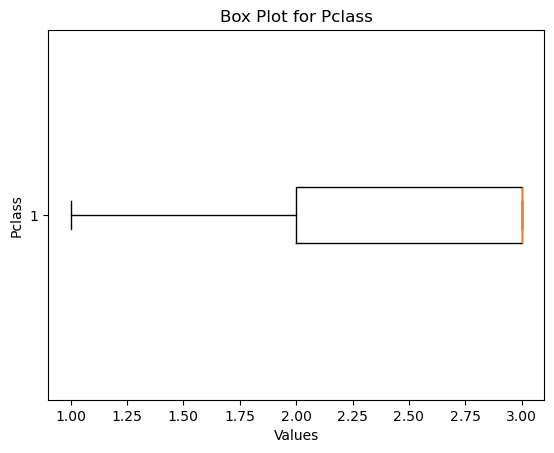

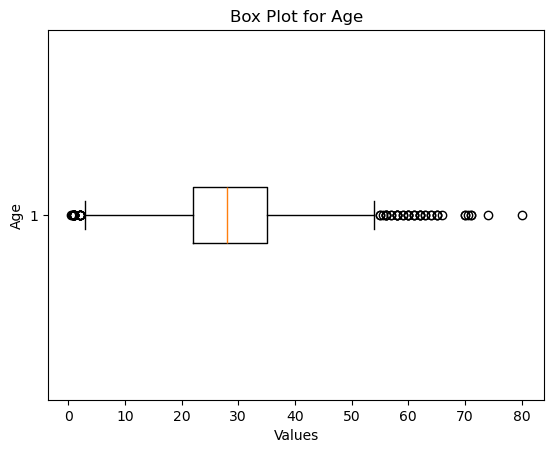

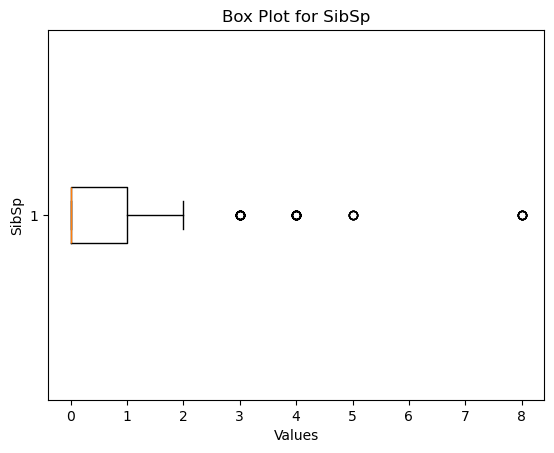

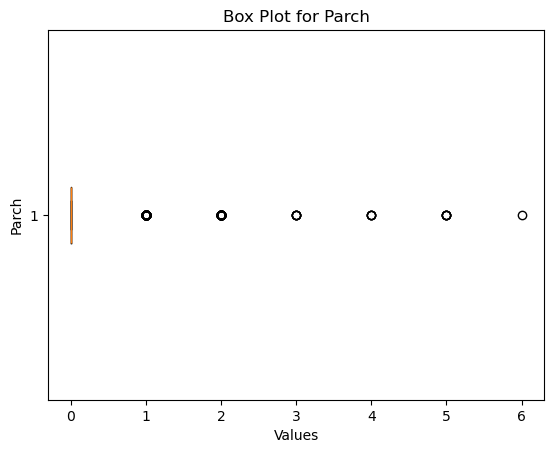

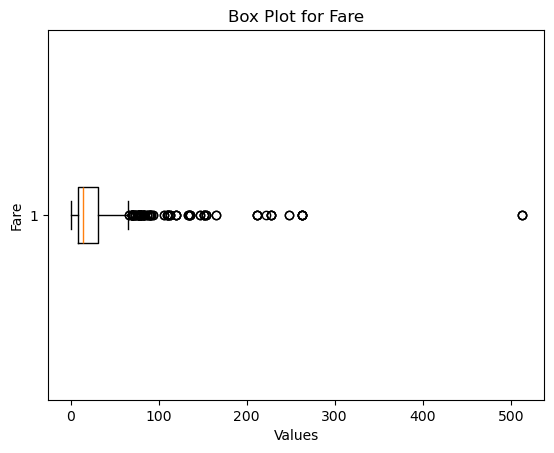

In [17]:
columns_to_plot = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
for column in columns_to_plot:
    plt.figure()
    plt.boxplot(df[column], vert=False)
    plt.ylabel(column)
    plt.xlabel('Values')
    plt.title(f'Box Plot for {column}')
    plt.show()

In [18]:
# calculate summary statistics 
d=df.select_dtypes(include=[np.number])
df1 = pd.DataFrame()
for column in columns_to_plot:
    mean = d[column].mean() 
    std = d[column].std() 
    
    # Calculate the lower and upper bounds 
    lower_bound = mean - std * 2
    upper_bound = mean + std * 2
    
    print('Lower Bound for', column, ':', lower_bound) 
    print('Upper Bound for', column, ':', upper_bound) 
    print("-------------")
    # Drop the outliers
    df1[column] = d[(d[column] >= lower_bound) & (d[column] <= upper_bound)][column]
#  nanعند حصر المجال بهذه الطريقه وحذف القيم خارج هذا المجال سيؤدي الي وجود قيم 
#  IsolationForest على عكس 

Lower Bound for Survived : -0.5893465246913332
Upper Bound for Survived : 1.3570232923681007
-------------
Lower Bound for Pclass : 0.6364994933545394
Upper Bound for Pclass : 3.980784457262745
-------------
Lower Bound for Age : 3.322189389636101
Upper Bound for Age : 55.40097559352888
-------------
Lower Bound for SibSp : -1.6824790082456653
Upper Bound for SibSp : 2.728494720928045
-------------
Lower Bound for Parch : -1.2305207273328636
Upper Bound for Parch : 1.9937081571869602
-------------
Lower Bound for Fare : -67.18264922578717
Upper Bound for Fare : 131.59106516293645
-------------


In [19]:
df1.isnull().sum()

Survived     0
Pclass       0
Age         70
SibSp       46
Parch       95
Fare        38
dtype: int64

In [20]:
imputer=SimpleImputer(strategy="median")
imputer.fit(df1)
df1=imputer.transform(df1)

In [21]:
df1.isnull().sum()

Survived    0
Pclass      0
Age         0
SibSp       0
Parch       0
Fare        0
dtype: int64

In [22]:
df1.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,28.705948,0.297419,0.132435,23.534474
std,0.486592,0.836071,9.647143,0.521648,0.339154,23.429525
min,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,24.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,13.000000
75%,1.000000,3.000000,33.000000,1.000000,0.000000,27.750000
max,1.000000,3.000000,55.000000,2.000000,1.000000,120.000000


In [23]:
df1.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [24]:
#Data Encoding 

In [25]:
df.describe(include=[object])

,Sex,Ticket,Embarked
count,891,891,891
unique,2,681,3
top,male,347082,S
freq,577,7,646


In [26]:
#using OneHot Encoder for columns: State-gov, Bachelors, Never-married,
#Occupation, Relationship, Race, Gender, Native Country--->more than 5 values
from sklearn.preprocessing import OneHotEncoder
d0=df.select_dtypes(include=[object])

columns_to_encode = ['Sex', 'Ticket', 'Embarked']
onehot_encoder = OneHotEncoder(sparse_output=False)

onehot_encoder = onehot_encoder.fit(d0)

df2 = onehot_encoder.transform(d0)

In [27]:
df2.columns

Index(['Sex_female', 'Sex_male', 'Ticket_110152', 'Ticket_110413',
       'Ticket_110465', 'Ticket_110564', 'Ticket_110813', 'Ticket_111240',
       'Ticket_111320', 'Ticket_111361',
       ...
       'Ticket_W./C. 14263', 'Ticket_W./C. 6607', 'Ticket_W./C. 6608',
       'Ticket_W./C. 6609', 'Ticket_W.E.P. 5734', 'Ticket_W/C 14208',
       'Ticket_WE/P 5735', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object', length=686)

In [28]:
#Merge number columns with text columns after encoding
df3=pd.merge(df2, df1, left_index=True, right_index=True)

In [29]:
df3.columns

Index(['Sex_female', 'Sex_male', 'Ticket_110152', 'Ticket_110413',
       'Ticket_110465', 'Ticket_110564', 'Ticket_110813', 'Ticket_111240',
       'Ticket_111320', 'Ticket_111361',
       ...
       'Ticket_WE/P 5735', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
       'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'],
      dtype='object', length=692)

In [30]:
df3.describe()

,Sex_female,Sex_male,Ticket_110152,Ticket_110413,Ticket_110465,Ticket_110564,Ticket_110813,Ticket_111240,Ticket_111320,Ticket_111361,...,Ticket_WE/P 5735,Embarked_C,Embarked_Q,Embarked_S,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,...,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.352413,0.647587,0.003367,0.003367,0.002245,0.001122,0.001122,0.001122,0.001122,0.002245,...,0.002245,0.188552,0.086420,0.725028,0.383838,2.308642,28.705948,0.297419,0.132435,23.534474
std,0.477990,0.477990,0.057961,0.057961,0.047351,0.033501,0.033501,0.033501,0.033501,0.047351,...,0.047351,0.391372,0.281141,0.446751,0.486592,0.836071,9.647143,0.521648,0.339154,23.429525
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,24.000000,0.000000,0.000000,7.910400
50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,28.000000,0.000000,0.000000,13.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,33.000000,1.000000,0.000000,27.750000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,55.000000,2.000000,1.000000,120.000000


In [31]:
print(df3["Survived"].value_counts())

Survived
0.0    549
1.0    342
Name: count, dtype: int64


In [32]:
from sklearn.preprocessing import MinMaxScaler 
  
df4 = pd.DataFrame()
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(df3)
df4 = pd.DataFrame(scaled_array, columns=df3.columns)
df4.head()

,Sex_female,Sex_male,Ticket_110152,Ticket_110413,Ticket_110465,Ticket_110564,Ticket_110813,Ticket_111240,Ticket_111320,Ticket_111361,...,Ticket_WE/P 5735,Embarked_C,Embarked_Q,Embarked_S,Survived,Pclass,Age,SibSp,Parch,Fare
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.352941,0.5,0.0,0.060417
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.666667,0.5,0.0,0.594027
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.431373,0.0,0.0,0.066042
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.607843,0.5,0.0,0.442500
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.607843,0.0,0.0,0.067083


In [33]:
X = df4.loc[:, df4.columns != 'Survived']
Y = df4['Survived']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state=42)

Minimum error: 0.19776119402985073 at K = 2


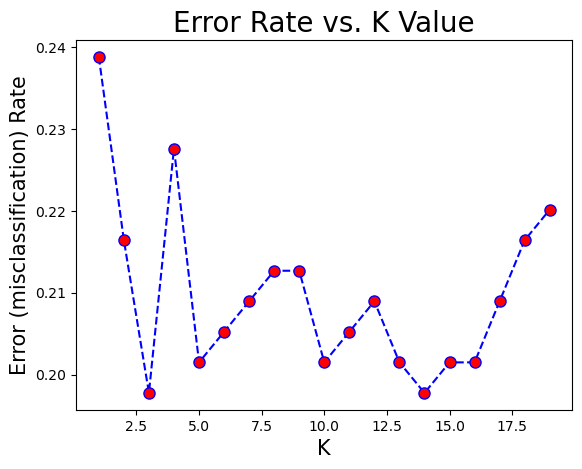

In [34]:
from sklearn.metrics import classification_report,\
    confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
error_rate = []
for i in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
plt.plot(range(1,20),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Error Rate vs. K Value', fontsize=20)
plt.xlabel('K',fontsize=15)
plt.ylabel('Error (misclassification) Rate',fontsize=15)
print("Minimum error:",min(error_rate),"at K =",error_rate.index(min(error_rate)))
K = error_rate.index(min(error_rate))

Accuracy =  0.7835820895522388
[[149   8]
 [ 50  61]]
              precision    recall  f1-score   support

         0.0       0.75      0.95      0.84       157
         1.0       0.88      0.55      0.68       111

    accuracy                           0.78       268
   macro avg       0.82      0.75      0.76       268
weighted avg       0.80      0.78      0.77       268



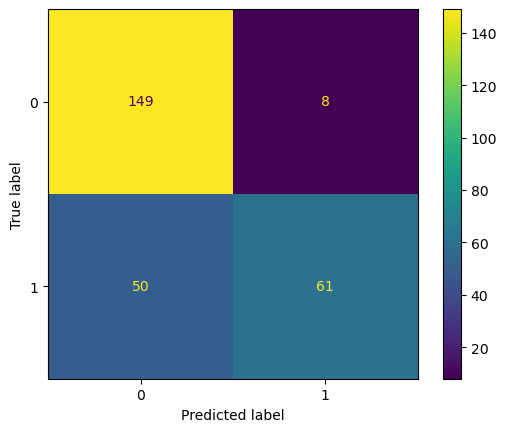

In [35]:
knn3 = KNeighborsClassifier(n_neighbors= K)
knn3.fit(X_train, y_train)
pred3 = knn3.predict(X_test)
from sklearn.metrics import accuracy_score 
accuracy3 = accuracy_score(y_test, pred3)

print('Accuracy = ', accuracy3)
print(confusion_matrix(y_test, pred3))
print(classification_report(y_test, pred3))
from sklearn import metrics
import matplotlib.pyplot as plt

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, pred3), display_labels = [0, 1])

cm_display.plot()
plt.show()

Accuracy =  0.7873134328358209
[[132  25]
 [ 32  79]]
              precision    recall  f1-score   support

         0.0       0.80      0.84      0.82       157
         1.0       0.76      0.71      0.73       111

    accuracy                           0.79       268
   macro avg       0.78      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



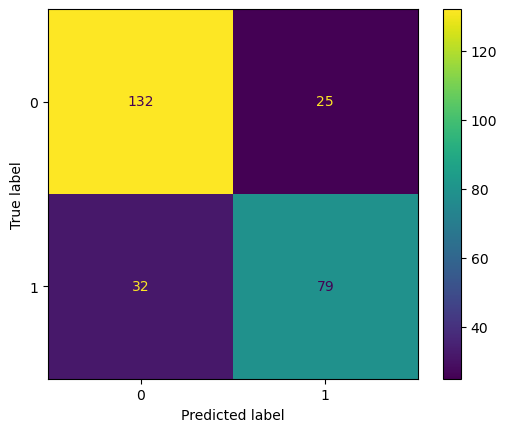

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, pred_dt)
print('Accuracy = ', accuracy_dt)
print(confusion_matrix(y_test, pred_dt))
print(classification_report(y_test, pred_dt))
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred_dt), display_labels=[0, 1])
cm_display.plot()
plt.show()


Accuracy =  0.8134328358208955
[[141  16]
 [ 34  77]]
              precision    recall  f1-score   support

         0.0       0.81      0.90      0.85       157
         1.0       0.83      0.69      0.75       111

    accuracy                           0.81       268
   macro avg       0.82      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



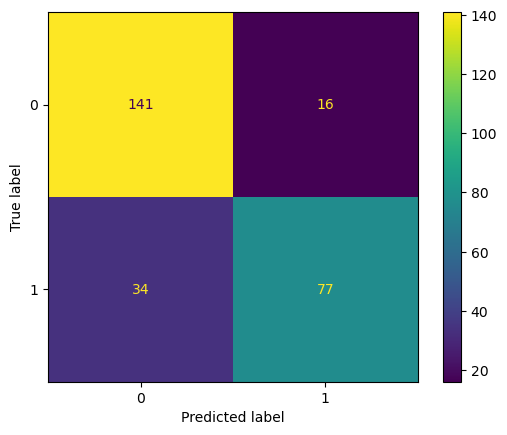

In [37]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, pred_svm)
print('Accuracy = ', accuracy_svm)
print(confusion_matrix(y_test, pred_svm))
print(classification_report(y_test, pred_svm))
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred_svm), display_labels=[0, 1])
cm_display.plot()
plt.show()


Logistic Regression Accuracy =  0.7985074626865671
[[135  22]
 [ 32  79]]
              precision    recall  f1-score   support

         0.0       0.81      0.86      0.83       157
         1.0       0.78      0.71      0.75       111

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



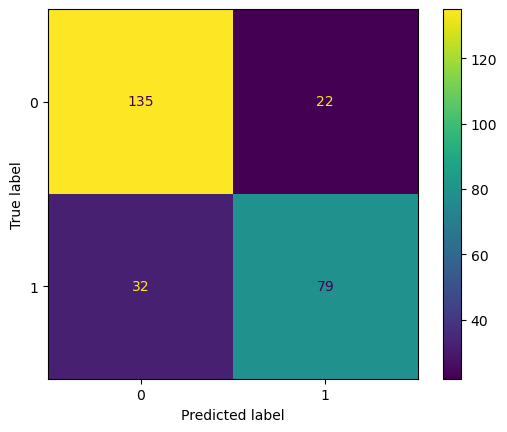

In [38]:
### Logistic Regression:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, pred_lr)
print('Logistic Regression Accuracy = ', accuracy_lr)
print(confusion_matrix(y_test, pred_lr))
print(classification_report(y_test, pred_lr))
cm_display_lr = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred_lr), display_labels=[0, 1])
cm_display_lr.plot()
plt.show()

Random Forest Accuracy =  0.8171641791044776
[[147  10]
 [ 39  72]]
              precision    recall  f1-score   support

         0.0       0.79      0.94      0.86       157
         1.0       0.88      0.65      0.75       111

    accuracy                           0.82       268
   macro avg       0.83      0.79      0.80       268
weighted avg       0.83      0.82      0.81       268



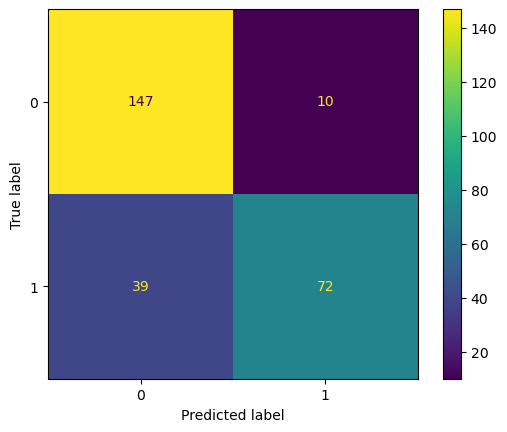

In [39]:
### Random Forest:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, pred_rf)
print('Random Forest Accuracy = ', accuracy_rf)
print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))
cm_display_rf = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred_rf), display_labels=[0, 1])
cm_display_rf.plot()
plt.show()

Ensemble Methods Accuracy =  0.8097014925373134
[[147  10]
 [ 41  70]]
              precision    recall  f1-score   support

         0.0       0.78      0.94      0.85       157
         1.0       0.88      0.63      0.73       111

    accuracy                           0.81       268
   macro avg       0.83      0.78      0.79       268
weighted avg       0.82      0.81      0.80       268



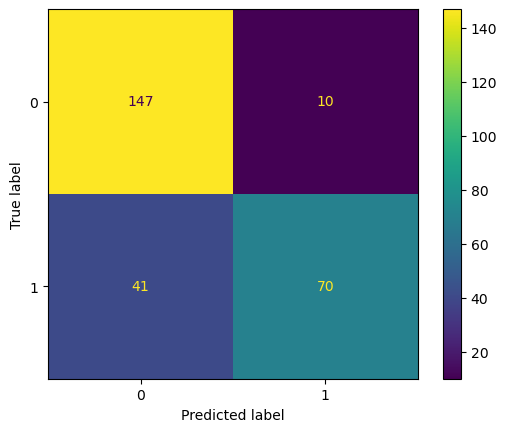

In [40]:
### Ensemble Methods (Voting Classifier):
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
lr = LogisticRegression()
rf = RandomForestClassifier()
ensemble = VotingClassifier(estimators=[('lr', lr), ('rf', rf)], voting='hard')
ensemble.fit(X_train, y_train)
pred_ensemble = ensemble.predict(X_test)
accuracy_ensemble = accuracy_score(y_test, pred_ensemble)
print('Ensemble Methods Accuracy = ', accuracy_ensemble)
print(confusion_matrix(y_test, pred_ensemble))
print(classification_report(y_test, pred_ensemble))
cm_display_ensemble = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred_ensemble), display_labels=[0, 1])
cm_display_ensemble.plot()
plt.show()